In [ ]:
import pandas as pd 
import seaborn as sns 


In [10]:
df = pd.read_csv("C:/Users/mohda/Desktop/MacLrn/datasets/housing.csv")

In [11]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [14]:
df.shape

(20640, 10)

In [16]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [18]:
df['total_bedrooms'].fillna(df['total_rooms'].median(),inplace=True)

In [19]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

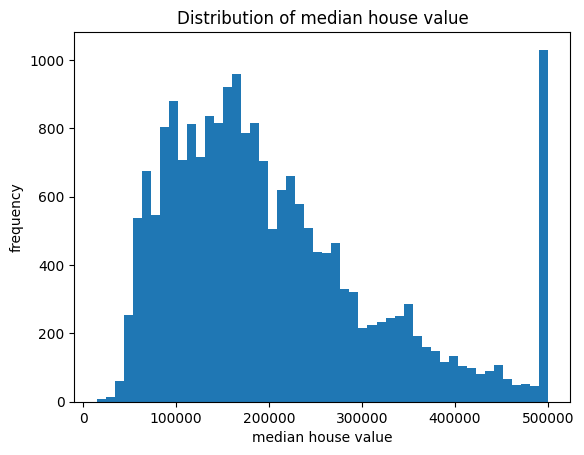

In [20]:
import matplotlib.pyplot as plt

plt.hist(df['median_house_value'],bins=50)
plt.xlabel('median house value')
plt.ylabel('frequency')
plt.title('Distribution of median house value')
plt.show()

In [21]:
df['median_house_value'].skew()

np.float64(0.9777632739098342)

In [22]:
import numpy as np 

df['median_house_value'] = np.log(df['median_house_value'])

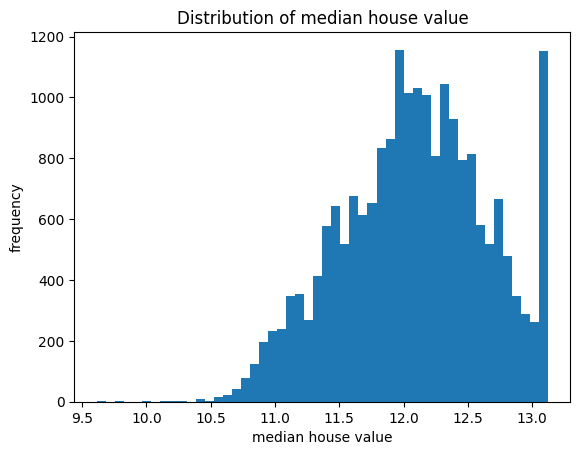

In [23]:
plt.hist(df['median_house_value'],bins=50)
plt.xlabel('median house value')
plt.ylabel('frequency')
plt.title('Distribution of median house value')
plt.show()

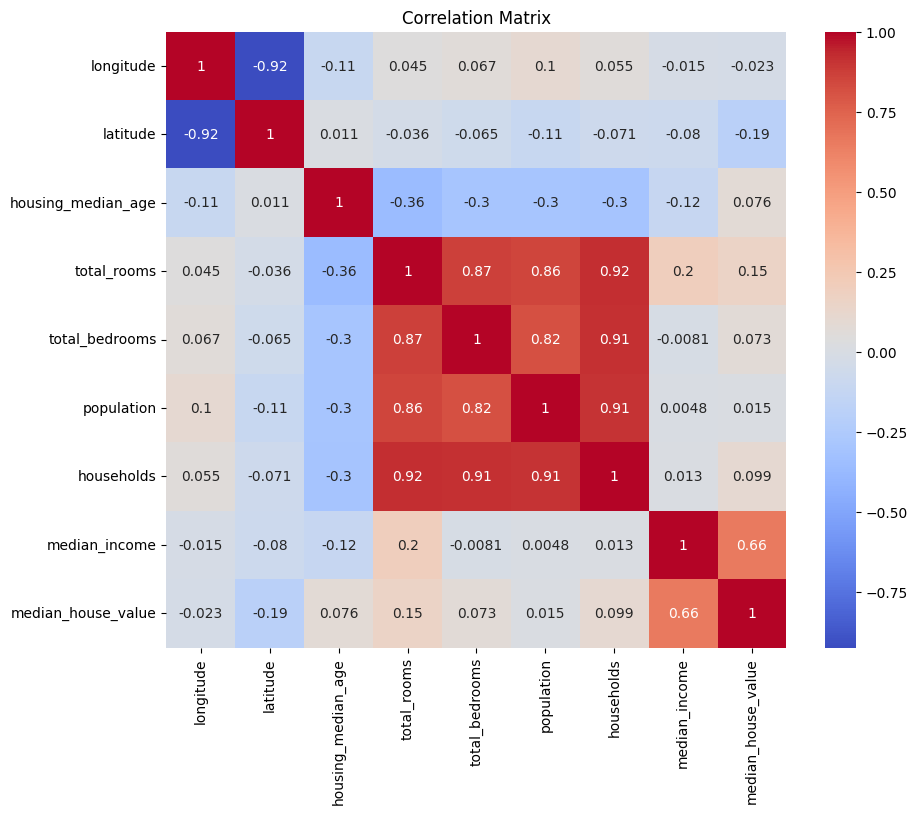

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
no_bay = df.drop(['ocean_proximity'],axis=1)
plt.figure(figsize=(10,8))
sns.heatmap(no_bay.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

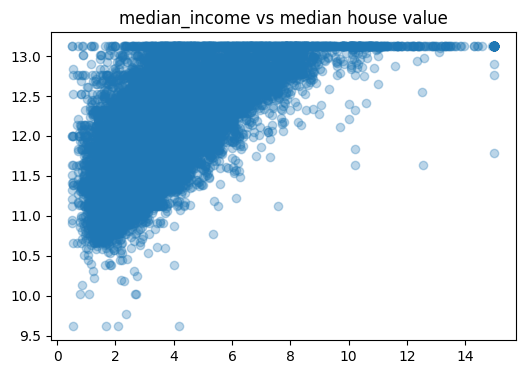

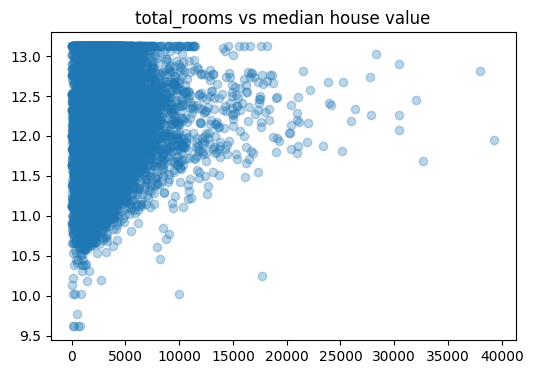

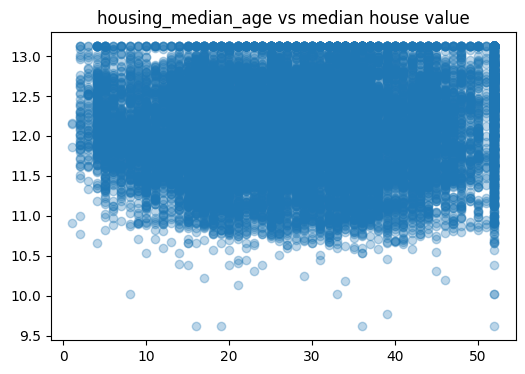

In [30]:
features = ['median_income', 'total_rooms', 'housing_median_age']

for col in features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col],df['median_house_value'],alpha=0.3)
    plt.title(f"{col} vs median house value")
    plt.show()

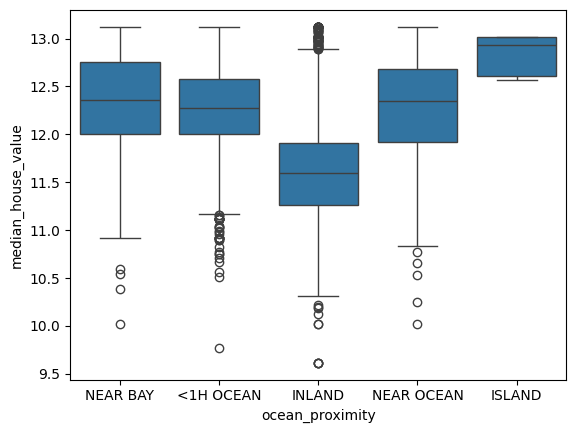

In [31]:
sns.boxplot(x='ocean_proximity',y='median_house_value',data=df)
plt.show()

In [33]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,13.022764,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,12.789684,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,12.771671,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,12.740517,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,12.743151,NEAR BAY


In [34]:
X = df.drop(['median_house_value'],axis=1)
y = df['median_house_value']

In [58]:
from sklearn.model_selection  import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X ,y, test_size=0.2,random_state=42)

In [59]:
numerical_features = ['housing_median_age','total_rooms','total_bedrooms','population','households','median_income','longitude','latitude']

categorical_features = ['ocean_proximity']

In [60]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer

num_transformer = StandardScaler()


cat_transformer = OneHotEncoder(handle_unknown = 'ignore')

preprocessing = ColumnTransformer(
    transformers = [
        ('num', num_transformer, numerical_features),
        ('cat',cat_transformer, categorical_features)
    ]
)



In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline 

model = Pipeline(steps = [
    ('preprocessor',preprocessing),
    ('regressor',LinearRegression())
])

In [62]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [63]:
y_pred_log = model.predict(X_test)

In [64]:
y_pred = np.exp(y_pred_log)


In [65]:
from sklearn.model_selection import cross_val_score

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np 


score = cross_val_score(model,X_train,y_train,cv=5,scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-score)

print(f"RMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean()}")

RMSE scores: [0.32880759 0.32418749 0.32315716 0.32837522 0.33780259]
Mean RMSE: 0.328466008344594


In [68]:
# Fit model
model.fit(X_train, y_train)
y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)  # inverse log

# Metrics
mae = mean_absolute_error(np.exp(y_test), y_pred)
mse = mean_squared_error(np.exp(y_test), y_pred)
rmse = np.sqrt(mse)


print("MAE:", mae)
print("RMSE:", rmse)



MAE: 57840.12829906714
RMSE: 102440.29419335826


In [69]:
from sklearn.linear_model import Ridge 

rg_model = Pipeline(steps = [
    ('preprosessor',preprocessing),
    ('regressor',Ridge())
])

In [72]:
from sklearn.linear_model import Lasso

ls_model = Pipeline(
    steps=[('preprosessor',preprocessing),
    ('regressor',Lasso())]
    )

In [73]:
from sklearn.tree import DecisionTreeRegressor

treee_model = Pipeline(steps=[('preprosessor',preprocessing),
    ('regressor',DecisionTreeRegressor())])

In [74]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[('preprosessor',preprocessing),
    ('regressor',RandomForestRegressor())]
)

In [77]:
from sklearn.model_selection import GridSearchCV 

param_grid = {
    'regressor__alpha':[0.01,0.1,1,10,100]
}

grid_ridge = GridSearchCV(
    rg_model ,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    
    # n_jobs=-1
)
grid_ridge.fit(X_train,y_train)

print(grid_ridge.best_params_)
print(grid_ridge.best_score_)
print(grid_ridge.best_estimator_)


{'regressor__alpha': 0.1}
-0.10791632472806703
Pipeline(steps=[('preprosessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income', 'longitude',
                                                   'latitude']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ocean_proximity'])])),
                ('regressor', Ridge(alpha=0.1))])


In [79]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'regressor__n_estimators':[10,20,30],
    'regressor__max_depth':[None,10,20,30],
    'regressor__min_samples_split':[2,5,10]
}

random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist,
    cv=5,
    scoring='neg_mean_squared_error',
    n_iter=10,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)
print(random_search.best_estimator_)


{'regressor__n_estimators': 30, 'regressor__min_samples_split': 10, 'regressor__max_depth': 20}
-0.055556899149106595
Pipeline(steps=[('preprosessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income', 'longitude',
                                                   'latitude']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ocean_proximity'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=20, min_samples_split=10,
              

In [80]:
best_model = random_search.best_estimator_

best_model.fit(X_train, y_train)

y_pred_log = best_model.predict(X_test)
y_pred = np.exp(y_pred_log)


In [82]:
from sklearn.metrics import r2_score

print("Final RMSE:", np.sqrt(mean_squared_error(np.exp(y_test), y_pred)))
print("Final R2:", r2_score(np.exp(y_test), y_pred))


Final RMSE: 50014.15362179862
Final R2: 0.8091118418722385


In [83]:
importances = best_model.named_steps['regressor'].feature_importances_


In [84]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,13.022764,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,12.789684,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,12.771671,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,12.740517,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,12.743151,NEAR BAY


In [85]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

In [86]:
df['lat_bin'] = pd.cut(df['latitude'],bins=10)
df['long_bin'] = pd.cut(df['longitude'], bins=10)

In [87]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline


In [88]:
xgb_model = Pipeline(steps=[
    ('preprocessor',preprocessing),
    ('regressor',XGBRegressor(
        objective='reg:squarederror',
        n_estimators=200,
        learning_ratio=0.1,
        max_dept=6,
        random_state=42
    ))
])

In [89]:
xgb_model.fit(X_train,y_train)

c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:30:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "learning_ratio", "max_dept" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [90]:
y_pred_log = xgb_model.predict(X_test)
y_pred = np.exp(y_pred_log)


In [92]:
from sklearn.metrics import mean_squared_error, r2_score

import numpy as np 


rmse = np.sqrt(mean_squared_error(np.exp(y_test), y_pred))
r2 = r2_score(np.exp(y_test), y_pred)

print(f"RMSE: {rmse}")
print(f"R2: {r2}")

RMSE: 49841.39783335891
R2: 0.810428272452932


In [94]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'regressor__n_estimators': [10, 20, 30],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0]
}

In [95]:
xgb_search = RandomizedSearchCV(
    xgb_model,
    param_distributions = param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print(xgb_search.best_params_)
print(xgb_search.best_score_)
print(xgb_search.best_estimator_)

{'regressor__subsample': 1.0, 'regressor__n_estimators': 20, 'regressor__max_depth': 5, 'regressor__learning_rate': 0.1, 'regressor__colsample_bytree': 0.8}
-0.08308132826151159
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income', 'longitude',
                                                   'latitude']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ocean_proximity'])])),
                ('regressor',
                 XGBRegressor

c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:35:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "learning_ratio", "max_dept" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [97]:
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline 

In [99]:
lgbm_model = Pipeline(steps=[
    ('preprocessor',preprocessing),
    ('regressor',LGBMRegressor(
        objective = 'regression',
        n_estimators=200,
        learning_rate=0.1,
        max_depth=-1,
        random_state=42
    ))
])

In [100]:
lgbm_model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1846
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 12
[LightGBM] [Info] Start training from score 12.086494


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [101]:
y_pred_log = lgbm_model.predict(X_test)
y_pred = np.exp(y_pred_log)


c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [102]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(np.exp(y_test), y_pred))
r2 = r2_score(np.exp(y_test), y_pred)

print("LightGBM RMSE:", rmse)
print("LightGBM R2:", r2)


LightGBM RMSE: 47084.03508876682
LightGBM R2: 0.8308233233248895


In [104]:
from sklearn.model_selection import RandomizedSearchCV

param_dist={
    'regressor__n_estimators': [20, 30, 40],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__num_leaves': [31, 50, 70],
    'regressor__max_depth': [-1, 10, 20],
    'regressor__min_child_samples': [20, 40, 60]
}

In [105]:
lgbm_search = RandomizedSearchCV(
    lgbm_model ,
    param_distributions= param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

print(lgbm_search.best_params_)
print(lgbm_search.best_score_)
print(lgbm_search.best_estimator_)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1846
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 12
[LightGBM] [Info] Start training from score 12.086494
{'regressor__num_leaves': 50, 'regressor__n_estimators': 40, 'regressor__min_child_samples': 40, 'regressor__max_depth': 20, 'regressor__learning_rate': 0.1}
-0.24005979208147374
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income', 'longitude',
  

In [106]:
import joblib

In [107]:
joblib.dump(lgbm_model,'housing_price_lgbm.pkl')

['housing_price_lgbm.pkl']

In [110]:
loaded_model = joblib.load("housing_price_lgbm.pkl")


In [111]:
new_data = X_test.iloc[:5]   # ya real input

pred_log = loaded_model.predict(new_data)
pred_price = np.exp(pred_log)

print(pred_price)


[ 54293.43899515  74631.79227629 518192.44691528 250463.46471627
 282519.31125334]


c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
